# E-Commerce Customer Analytics — Exploratory Visualizations

This notebook produces the visualizations used in the project README and Tableau dashboard. The underlying analysis lives in the SQL files; this notebook focuses on translating those findings into clear visual narratives.

**Author:** Mubina Mirzaeva
**Dataset:** Olist Brazilian E-Commerce, 2016–2018
**Source queries:** `sql/00_setup.sql` through `sql/04_satisfaction_operations.sql`

In [2]:
%pip install seaborn psycopg2-binary pandas matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

# Visual styling for all charts in this notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

# Connect to the Olist database
conn = psycopg2.connect(
    dbname="olist",
    user="mubinamirzaeva",
    host="localhost",
    port=5432
)

print("Connected to Olist database.")

Connected to Olist database.


## Revenue Trend, 2017–2018

Olist's growth trajectory during the dataset window. Revenue is calculated from delivered orders only, with the truncated October 2018 partial month excluded for trend clarity.

/var/folders/_r/wy82kxwx1fx4tthd4qhw7knc0000gn/T/ipykernel_45683/1232594441.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  revenue_df = pd.read_sql(revenue_query, conn)


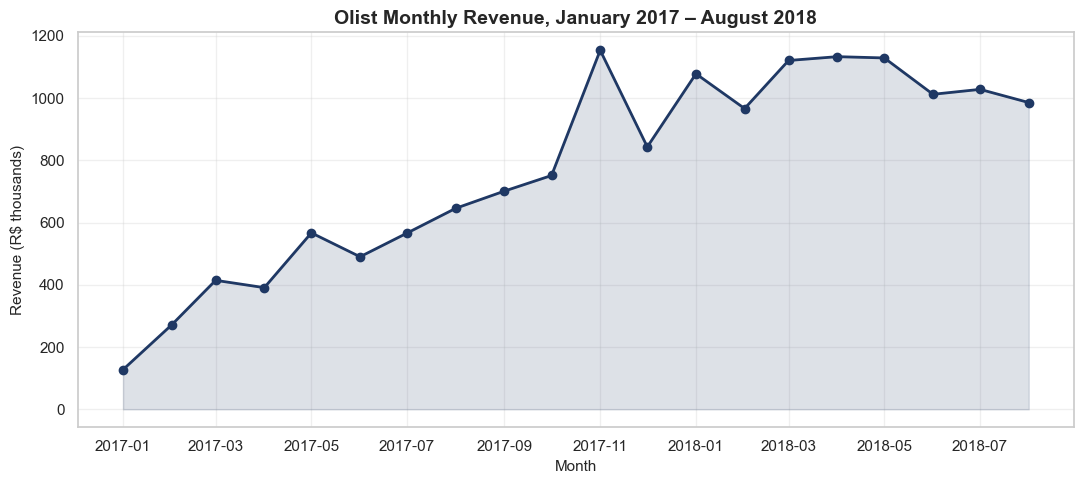

Total revenue over the period: R$15,373,120
Total orders over the period: 96,211


In [11]:
revenue_query = """
WITH order_revenue AS (
    SELECT
        oi.order_id,
        SUM(oi.price + oi.freight_value) AS order_total
    FROM order_items oi
    GROUP BY oi.order_id
)
SELECT
    DATE_TRUNC('month', o.order_purchase_timestamp)::DATE AS month,
    COUNT(DISTINCT o.order_id) AS orders,
    ROUND(SUM(orev.order_total)::NUMERIC, 2) AS revenue
FROM orders o
JOIN order_revenue orev ON o.order_id = orev.order_id
WHERE o.order_status = 'delivered'
  AND o.order_purchase_timestamp >= '2017-01-01'
  AND o.order_purchase_timestamp < '2018-09-01'
GROUP BY month
ORDER BY month;
"""

revenue_df = pd.read_sql(revenue_query, conn)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(revenue_df["month"], revenue_df["revenue"] / 1000, marker="o", linewidth=2, color="#1f3864")
ax.fill_between(revenue_df["month"], revenue_df["revenue"] / 1000, alpha=0.15, color="#1f3864")
ax.set_title("Olist Monthly Revenue, January 2017 – August 2018")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (R$ thousands)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../dashboard/01_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total revenue over the period: R${revenue_df['revenue'].sum():,.0f}")
print(f"Total orders over the period: {revenue_df['orders'].sum():,}")

## Customer Segment Distribution

Customers segmented using a two-tier RFM model. The Tier 1 segments (one-time buyers) are shown separately from Tier 2 (repeat buyers) because of the 50× difference in customer counts; combining them on one chart would render the repeat segments invisible.

/var/folders/_r/wy82kxwx1fx4tthd4qhw7knc0000gn/T/ipykernel_45683/1177736005.py:51: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  segments_df = pd.read_sql(segment_query, conn)


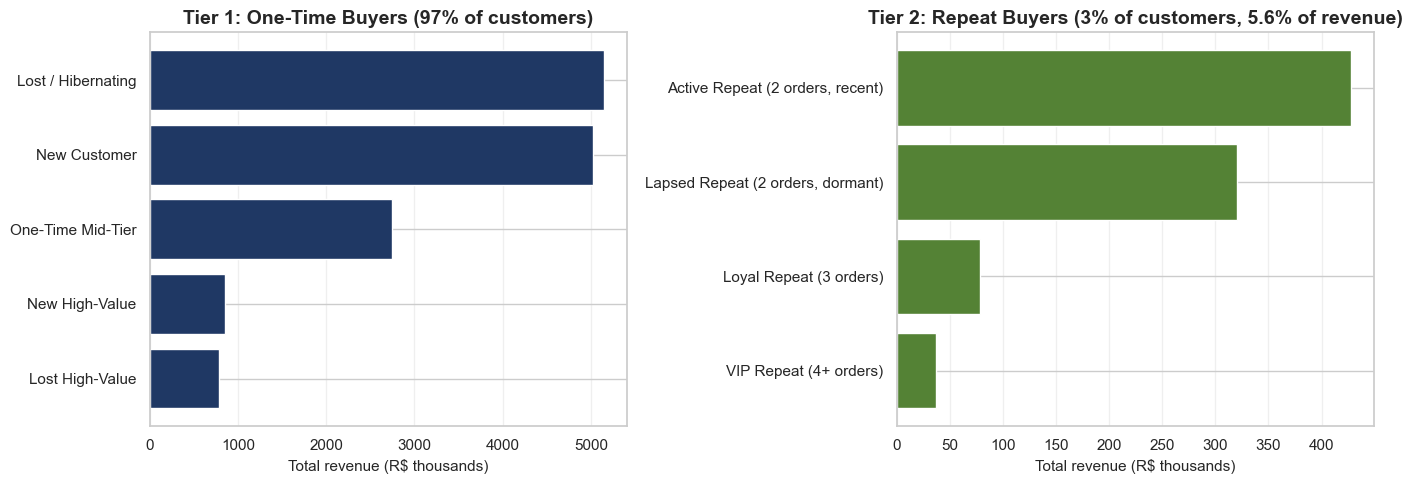

In [12]:
segment_query = """
WITH order_revenue AS (
    SELECT oi.order_id, SUM(oi.price + oi.freight_value) AS order_total
    FROM order_items oi GROUP BY oi.order_id
),
customer_orders AS (
    SELECT
        c.customer_unique_id, o.order_id,
        o.order_purchase_timestamp::DATE AS order_date,
        orev.order_total
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN order_revenue orev ON o.order_id = orev.order_id
    WHERE o.order_status = 'delivered'
),
rfm_raw AS (
    SELECT
        customer_unique_id,
        ('2018-10-17'::DATE - MAX(order_date)) AS recency_days,
        COUNT(DISTINCT order_id) AS frequency,
        ROUND(SUM(order_total)::NUMERIC, 2) AS monetary
    FROM customer_orders
    GROUP BY customer_unique_id
),
rfm_scored AS (
    SELECT
        customer_unique_id, recency_days, frequency, monetary,
        NTILE(5) OVER (ORDER BY recency_days ASC) AS r_score,
        NTILE(5) OVER (ORDER BY monetary DESC) AS m_score
    FROM rfm_raw
)
SELECT
    CASE
        WHEN frequency >= 4 THEN 'VIP Repeat (4+ orders)'
        WHEN frequency = 3 THEN 'Loyal Repeat (3 orders)'
        WHEN frequency = 2 AND r_score >= 3 THEN 'Active Repeat (2 orders, recent)'
        WHEN frequency = 2 THEN 'Lapsed Repeat (2 orders, dormant)'
        WHEN frequency = 1 AND r_score >= 4 AND m_score >= 4 THEN 'New High-Value'
        WHEN frequency = 1 AND r_score >= 4 THEN 'New Customer'
        WHEN frequency = 1 AND r_score <= 2 AND m_score >= 4 THEN 'Lost High-Value'
        WHEN frequency = 1 AND r_score <= 2 THEN 'Lost / Hibernating'
        ELSE 'One-Time Mid-Tier'
    END AS segment,
    COUNT(*) AS customers,
    ROUND(SUM(monetary)::NUMERIC, 2) AS total_revenue
FROM rfm_scored
GROUP BY segment
ORDER BY total_revenue DESC;
"""

segments_df = pd.read_sql(segment_query, conn)

tier2 = ["VIP Repeat (4+ orders)", "Loyal Repeat (3 orders)",
         "Active Repeat (2 orders, recent)", "Lapsed Repeat (2 orders, dormant)"]
segments_df["tier"] = segments_df["segment"].apply(
    lambda s: "Tier 2: Repeat Buyers" if s in tier2 else "Tier 1: One-Time Buyers"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier1_data = segments_df[segments_df["tier"] == "Tier 1: One-Time Buyers"].sort_values("total_revenue", ascending=True)
axes[0].barh(tier1_data["segment"], tier1_data["total_revenue"] / 1000, color="#1f3864")
axes[0].set_title("Tier 1: One-Time Buyers (97% of customers)")
axes[0].set_xlabel("Total revenue (R$ thousands)")
axes[0].grid(True, alpha=0.3, axis="x")

tier2_data = segments_df[segments_df["tier"] == "Tier 2: Repeat Buyers"].sort_values("total_revenue", ascending=True)
axes[1].barh(tier2_data["segment"], tier2_data["total_revenue"] / 1000, color="#548235")
axes[1].set_title("Tier 2: Repeat Buyers (3% of customers, 5.6% of revenue)")
axes[1].set_xlabel("Total revenue (R$ thousands)")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("../dashboard/02_segments.png", dpi=150, bbox_inches="tight")
plt.show()

## Cohort Retention Heatmap

The retention matrix shows the percentage of each cohort that returned to purchase in each subsequent month. Reading horizontally across any row reveals the retention decay curve for a single cohort. Reading vertically down any column reveals how retention has changed across acquisition periods. The dominant pattern is that retention is structurally low across all cohorts.

/var/folders/_r/wy82kxwx1fx4tthd4qhw7knc0000gn/T/ipykernel_45683/2370648596.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cohort_df = pd.read_sql(cohort_query, conn)


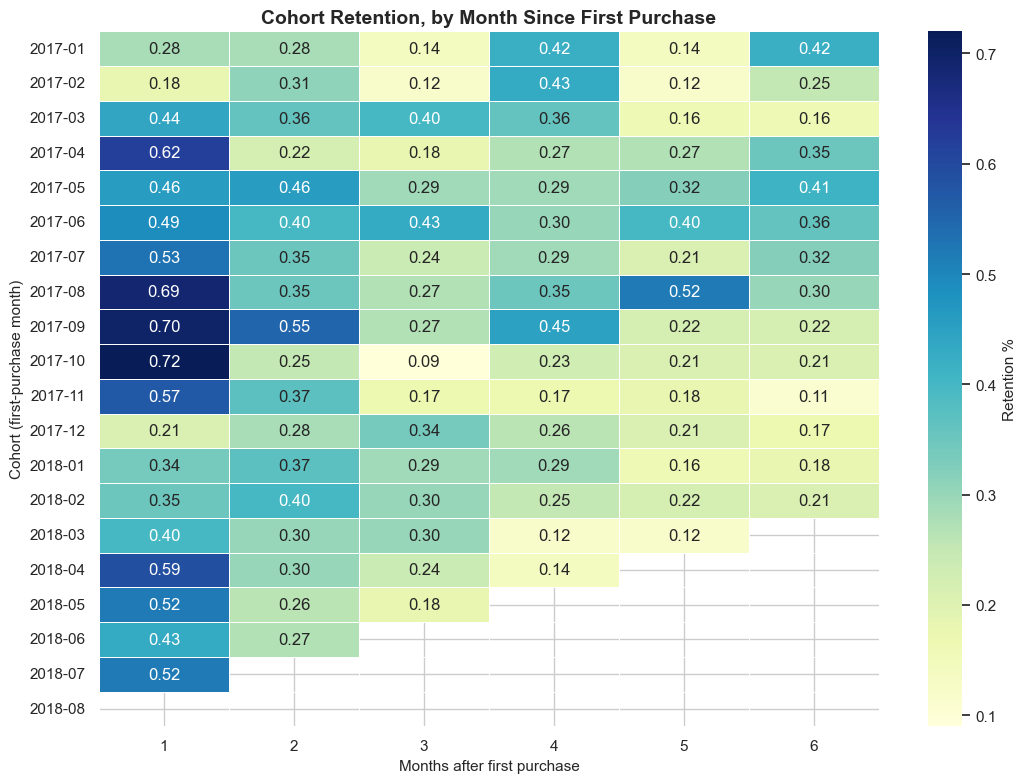

In [13]:
cohort_query = """
WITH first_orders AS (
    SELECT
        c.customer_unique_id,
        DATE_TRUNC('month', MIN(o.order_purchase_timestamp))::DATE AS cohort_month
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
customer_activity AS (
    SELECT
        fo.customer_unique_id,
        fo.cohort_month,
        (EXTRACT(YEAR FROM o.order_purchase_timestamp)::INT - EXTRACT(YEAR FROM fo.cohort_month)::INT) * 12
        + (EXTRACT(MONTH FROM o.order_purchase_timestamp)::INT - EXTRACT(MONTH FROM fo.cohort_month)::INT)
        AS month_index
    FROM first_orders fo
    JOIN customers c ON fo.customer_unique_id = c.customer_unique_id
    JOIN orders o ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
),
cohort_sizes AS (
    SELECT cohort_month, COUNT(DISTINCT customer_unique_id) AS cohort_size
    FROM first_orders GROUP BY cohort_month
)
SELECT
    ca.cohort_month,
    ca.month_index,
    ROUND(100.0 * COUNT(DISTINCT ca.customer_unique_id) / cs.cohort_size, 2) AS retention_pct
FROM customer_activity ca
JOIN cohort_sizes cs ON ca.cohort_month = cs.cohort_month
WHERE ca.cohort_month >= '2017-01-01'
  AND ca.month_index BETWEEN 0 AND 6
GROUP BY ca.cohort_month, ca.month_index, cs.cohort_size
ORDER BY ca.cohort_month, ca.month_index;
"""

cohort_df = pd.read_sql(cohort_query, conn)
cohort_df["cohort_month"] = pd.to_datetime(cohort_df["cohort_month"])
heatmap_data = cohort_df.pivot(index="cohort_month", columns="month_index", values="retention_pct")
heatmap_data.index = heatmap_data.index.strftime("%Y-%m")
heatmap_no_m0 = heatmap_data.drop(columns=[0])

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    heatmap_no_m0, annot=True, fmt=".2f", cmap="YlGnBu",
    cbar_kws={"label": "Retention %"}, linewidths=0.5, ax=ax
)
ax.set_title("Cohort Retention, by Month Since First Purchase")
ax.set_xlabel("Months after first purchase")
ax.set_ylabel("Cohort (first-purchase month)")
plt.tight_layout()
plt.savefig("../dashboard/03_cohort_retention.png", dpi=150, bbox_inches="tight")
plt.show()

## Delivery Performance and Review Scores

Two views of the relationship between delivery experience and review outcomes. The left panel shows the unconditional relationship between delivery speed and average review score. The right panel reveals that estimate accuracy carries independent explanatory power: within any delivery-speed band, missing the promised delivery window substantially increases the negative-review rate.

/var/folders/_r/wy82kxwx1fx4tthd4qhw7knc0000gn/T/ipykernel_45683/3529370826.py:45: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  simple_df = pd.read_sql(delivery_simple_query, conn)
/var/folders/_r/wy82kxwx1fx4tthd4qhw7knc0000gn/T/ipykernel_45683/3529370826.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  interaction_df = pd.read_sql(delivery_interaction_query, conn)


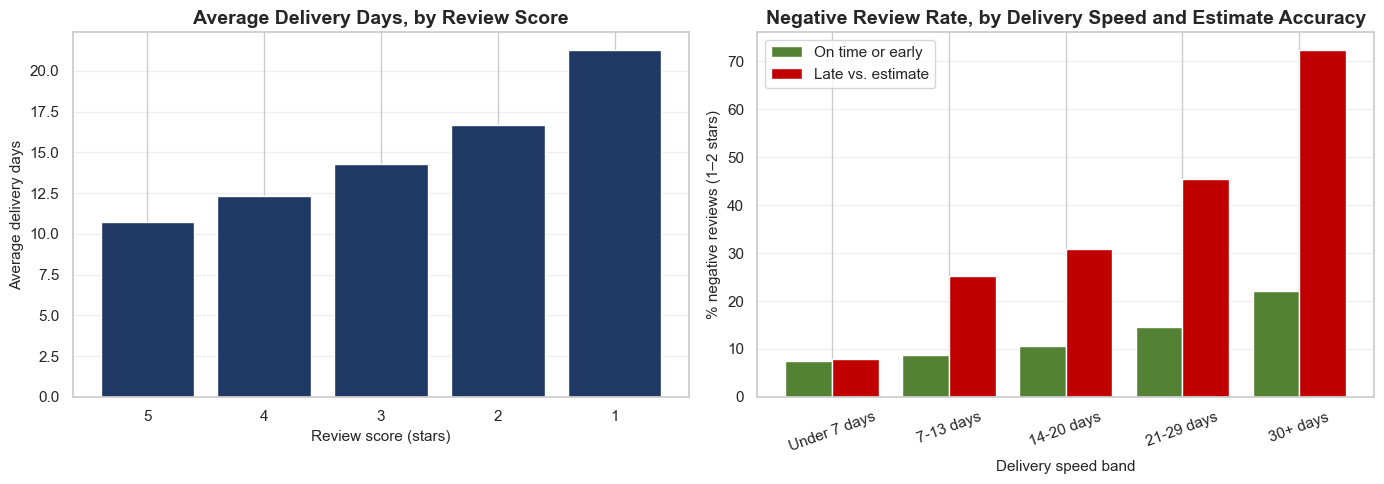

In [14]:
delivery_simple_query = """
SELECT
    r.review_score,
    ROUND(AVG(EXTRACT(EPOCH FROM (o.order_delivered_customer_date - o.order_purchase_timestamp))/86400)::NUMERIC, 1)
        AS avg_delivery_days,
    ROUND(100.0 * COUNT(*) FILTER (WHERE o.order_delivered_customer_date > o.order_estimated_delivery_date) / COUNT(*), 1)
        AS pct_delivered_late
FROM order_reviews r
JOIN orders o ON r.order_id = o.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY r.review_score
ORDER BY r.review_score DESC;
"""

delivery_interaction_query = """
WITH delivery_data AS (
    SELECT
        r.review_score,
        EXTRACT(EPOCH FROM (o.order_delivered_customer_date - o.order_purchase_timestamp))/86400 AS delivery_days,
        EXTRACT(EPOCH FROM (o.order_delivered_customer_date - o.order_estimated_delivery_date))/86400 AS days_vs_estimate
    FROM order_reviews r
    JOIN orders o ON r.order_id = o.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
)
SELECT
    CASE
        WHEN delivery_days < 7 THEN 'Under 7 days'
        WHEN delivery_days < 14 THEN '7-13 days'
        WHEN delivery_days < 21 THEN '14-20 days'
        WHEN delivery_days < 30 THEN '21-29 days'
        ELSE '30+ days'
    END AS delivery_band,
    CASE
        WHEN days_vs_estimate <= 0 THEN 'On time or early'
        ELSE 'Late'
    END AS estimate_status,
    ROUND(100.0 * COUNT(*) FILTER (WHERE review_score <= 2) / COUNT(*), 1) AS pct_negative
FROM delivery_data
GROUP BY delivery_band, estimate_status
ORDER BY delivery_band, estimate_status;
"""

simple_df = pd.read_sql(delivery_simple_query, conn)
interaction_df = pd.read_sql(delivery_interaction_query, conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(simple_df["review_score"].astype(str), simple_df["avg_delivery_days"], color="#1f3864")
axes[0].set_title("Average Delivery Days, by Review Score")
axes[0].set_xlabel("Review score (stars)")
axes[0].set_ylabel("Average delivery days")
axes[0].grid(True, alpha=0.3, axis="y")

band_order = ["Under 7 days", "7-13 days", "14-20 days", "21-29 days", "30+ days"]
pivot = interaction_df.pivot(index="delivery_band", columns="estimate_status", values="pct_negative").reindex(band_order)
x = range(len(pivot.index))
axes[1].bar([i - 0.2 for i in x], pivot["On time or early"], width=0.4, label="On time or early", color="#548235")
axes[1].bar([i + 0.2 for i in x], pivot["Late"], width=0.4, label="Late vs. estimate", color="#c00000")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(pivot.index, rotation=20)
axes[1].set_title("Negative Review Rate, by Delivery Speed and Estimate Accuracy")
axes[1].set_xlabel("Delivery speed band")
axes[1].set_ylabel("% negative reviews (1–2 stars)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("../dashboard/04_delivery_reviews.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
conn.close()
print("Database connection closed.")
print("\nGenerated visualizations saved to dashboard/ folder:")
print("  01_revenue_trend.png")
print("  02_segments.png")
print("  03_cohort_retention.png")
print("  04_delivery_reviews.png")

Database connection closed.

Generated visualizations saved to dashboard/ folder:
  01_revenue_trend.png
  02_segments.png
  03_cohort_retention.png
  04_delivery_reviews.png
